# Model Evaluation for Reliability Engineering Q&A

This notebook evaluates different LLMs on answering reliability engineering questions.

**Pipeline:**
1. Load Q&A dataset
2. For each model, generate answers to questions
3. Use Gemini Flash to extract final answer from model response
4. Compare extracted answer to ground truth
5. Analyze results across models

## Setup and Imports

In [ ]:
import json
import re
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field
from openai import OpenAI
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import time

sys.path.insert(0, '..')
from utils.api_client import create_openrouter_client
from utils.data_io import load_dataset as _load_dataset

# Initialize OpenRouter client
client = create_openrouter_client()

# Token tracking
total_tokens = {}
token_lock = threading.Lock()

## Configuration

In [ ]:
@dataclass
class EvalConfig:
    """Evaluation configuration"""
    # Dataset
    dataset_path: str = "../data/synthetic_qra_dataset.jsonl"
    output_dir: str = "../results"
    
    # Models to evaluate
    models: List[str] = field(default_factory=lambda: [
        "qwen/qwen3-14b",          
        "deepseek/deepseek-r1-distill-qwen-14b",
        "openai/gpt-5-mini",                   
    ])
    
    # Answer extractor model (fast and cheap)
    extractor_model: str = "google/gemini-2.5-flash"
    
    # Evaluation settings
    sample_size: Optional[int] = 200  # None = use all, or set a number like 50 for testing
    max_workers: int = 5  # Parallel requests per model
    temperature: float = 0.1
    max_tokens: int = 2000

config = EvalConfig()
Path(config.output_dir).mkdir(exist_ok=True)

print(f"Configuration:")
print(f"  Dataset: {config.dataset_path}")
print(f"  Models to evaluate: {len(config.models)}")
for model in config.models:
    print(f"    - {model}")
print(f"  Answer extractor: {config.extractor_model}")
print(f"  Sample size: {config.sample_size or 'All'}")

## Load Dataset

In [ ]:
def load_dataset(config: EvalConfig) -> List[Dict]:
    """Load the Q&A dataset, with optional sampling."""
    dataset = _load_dataset(config.dataset_path)
    
    # Sample if specified
    if config.sample_size and config.sample_size < len(dataset):
        import random
        random.seed(42)  # Reproducible sampling
        dataset = random.sample(dataset, config.sample_size)
        print(f"Sampled {config.sample_size} questions from dataset")
    
    print(f"Loaded {len(dataset)} Q&A pairs")
    
    # Show sample
    if dataset:
        print(f"\nSample question:")
        print(f"  Source: {dataset[0]['source']}")
        print(f"  Question: {dataset[0]['question'][:150]}...")
        print(f"  Ground truth answer: {dataset[0]['answer']}")
    
    return dataset

# Load the dataset
dataset = load_dataset(config)

## Prompt Engineering

Carefully crafted prompt for reliability engineering questions.

In [4]:
EVALUATION_PROMPT = """You are an expert in reliability engineering, probability theory, and system analysis. 

A student has asked you the following question. Provide a clear, accurate answer.

IMPORTANT INSTRUCTIONS:
1. Read the question carefully and identify what is being asked
2. Show your reasoning step-by-step
3. Perform any necessary calculations accurately
4. At the end, clearly state your FINAL ANSWER
5. For multi-part questions (a, b, c, etc.), provide ALL answers
6. Format your final answer clearly - use numbers, comma-separated values, or True/False as appropriate

Question:
{question}

Please solve this problem step-by-step and provide your final answer."""


def format_prompt(question: str) -> str:
    """Format the evaluation prompt with a question"""
    return EVALUATION_PROMPT.format(question=question)


# Test the prompt
if dataset:
    print("Sample prompt:")
    print("="*80)
    print(format_prompt(dataset[0]['question'][:200] + "..."))
    print("="*80)

Sample prompt:
You are an expert in reliability engineering, probability theory, and system analysis. 

A student has asked you the following question. Provide a clear, accurate answer.

IMPORTANT INSTRUCTIONS:
1. Read the question carefully and identify what is being asked
2. Show your reasoning step-by-step
3. Perform any necessary calculations accurately
4. At the end, clearly state your FINAL ANSWER
5. For multi-part questions (a, b, c, etc.), provide ALL answers
6. Format your final answer clearly - use numbers, comma-separated values, or True/False as appropriate

Question:
** A manufacturing process has a historical defect rate with a prior estimate of 0.05 defects per unit, with a standard deviation of 0.02. A quality control inspection of a new batch reveals 8 defects...

Please solve this problem step-by-step and provide your final answer.


## Answer Extraction

Use Gemini Flash to extract the final answer from model responses.

In [5]:
EXTRACTION_PROMPT = """You are extracting the final answer from a model's response to a reliability engineering question.

The model may have provided reasoning, calculations, or thinking. Your job is to extract ONLY the final answer.

EXTRACTION RULES:
1. Look for phrases like "final answer", "the answer is", "therefore", "result"
2. Extract the numerical value(s), boolean (True/False), or expression
3. For multi-part answers, provide comma-separated values
4. Remove units, explanations, and extra text
5. If multiple numbers are given, extract all of them comma-separated
6. If no clear answer exists, respond with: "UNABLE_TO_EXTRACT"

EXAMPLES:
Model response: "After calculating, the reliability is 0.95 and the MTTF is 1000 hours."
Your extraction: "0.95, 1000"

Model response: "The system will fail, so the answer is False."
Your extraction: "False"

Model response: "Therefore, the final answer is approximately 0.8413."
Your extraction: "0.8413"

ORIGINAL QUESTION:
{question}

MODEL'S RESPONSE:
{model_response}

Extract ONLY the final answer (no explanation):"""


def extract_answer(question: str, model_response: str, config: EvalConfig) -> str:
    """Use Gemini Flash to extract the final answer from model response"""
    prompt = EXTRACTION_PROMPT.format(
        question=question,
        model_response=model_response
    )
    
    try:
        response = client.chat.completions.create(
            model=config.extractor_model,
            max_tokens=200,
            temperature=0.1,
            messages=[{"role": "user", "content": prompt}]
        )
        
        # Track tokens
        global total_tokens
        with token_lock:
            if config.extractor_model not in total_tokens:
                total_tokens[config.extractor_model] = 0
            total_tokens[config.extractor_model] += (
                response.usage.prompt_tokens + response.usage.completion_tokens
            )
        
        extracted = response.choices[0].message.content.strip()
        return extracted
        
    except Exception as e:
        print(f"Extraction error: {e}")
        return "EXTRACTION_ERROR"


# Test answer extraction
test_response = """Let me solve this step by step.

First, we calculate the probability using the formula P = 1 - e^(-λt).
Given λ = 0.01 and t = 100:
P = 1 - e^(-0.01 * 100) = 1 - e^(-1) = 1 - 0.368 = 0.632

For part b, we need to find the MTTF, which is 1/λ = 1/0.01 = 100 hours.

Therefore, the final answers are:
a) 0.632
b) 100"""

print("Testing answer extraction:")
print(f"Model response: {test_response[:100]}...")
extracted = extract_answer("Sample question", test_response, config)
print(f"Extracted answer: {extracted}")

Testing answer extraction:
Model response: Let me solve this step by step.

First, we calculate the probability using the formula P = 1 - e^(-λ...
Extracted answer: 0.632, 100


## Model Evaluation Functions

In [6]:
def call_model(model: str, question: str, config: EvalConfig) -> str:
    """Call a model with the question and return its response"""
    prompt = format_prompt(question)
    
    try:
        response = client.chat.completions.create(
            model=model,
            max_tokens=config.max_tokens,
            temperature=config.temperature,
            messages=[{"role": "user", "content": prompt}]
        )
        
        # Track tokens
        global total_tokens
        with token_lock:
            if model not in total_tokens:
                total_tokens[model] = 0
            total_tokens[model] += (
                response.usage.prompt_tokens + response.usage.completion_tokens
            )
        
        return response.choices[0].message.content
        
    except Exception as e:
        print(f"Error calling {model}: {e}")
        return f"ERROR: {str(e)}"


def normalize_answer(answer: str) -> str:
    """Normalize answer for comparison"""
    # Convert to lowercase
    answer = answer.lower().strip()
    
    # Remove common variations
    answer = answer.replace(" ", "")
    answer = answer.replace("×", "x")
    answer = answer.replace("^", "**")
    
    return answer


def compare_answers(predicted: str, ground_truth: str) -> Dict:
    """Compare predicted answer with ground truth"""
    # Normalize both
    pred_norm = normalize_answer(predicted)
    truth_norm = normalize_answer(ground_truth)
    
    # Exact match
    exact_match = pred_norm == truth_norm
    
    # Try to extract and compare numbers
    pred_numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', predicted)
    truth_numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', ground_truth)
    
    numerical_match = False
    if pred_numbers and truth_numbers:
        try:
            # Compare numbers with tolerance
            pred_nums = [float(x) for x in pred_numbers]
            truth_nums = [float(x) for x in truth_numbers]
            
            if len(pred_nums) == len(truth_nums):
                matches = [
                    abs(p - t) / max(abs(t), 1e-10) < 0.05  # 5% tolerance
                    for p, t in zip(pred_nums, truth_nums)
                ]
                numerical_match = all(matches)
        except:
            pass
    
    # Partial match (contains the answer)
    partial_match = truth_norm in pred_norm or pred_norm in truth_norm
    
    return {
        'exact_match': exact_match,
        'numerical_match': numerical_match,
        'partial_match': partial_match,
        'correct': exact_match or numerical_match or (partial_match and len(truth_norm) > 3)
    }


def evaluate_single_question(item: Dict, model: str, config: EvalConfig) -> Dict:
    """Evaluate a single question with a model"""
    question = item['question']
    ground_truth = item['answer']
    
    # Get model response
    model_response = call_model(model, question, config)
    
    # Extract answer from response
    extracted_answer = extract_answer(question, model_response, config)
    
    # Compare with ground truth
    comparison = compare_answers(extracted_answer, ground_truth)
    
    return {
        'source': item['source'],
        'question': question,
        'ground_truth': ground_truth,
        'model_response': model_response,
        'extracted_answer': extracted_answer,
        **comparison
    }


print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Run Evaluation (Parallel)

In [ ]:
def evaluate_model(model: str, dataset: List[Dict], config: EvalConfig) -> List[Dict]:
    """Evaluate a single model on the entire dataset (with parallelization)"""
    print(f"\n{'='*80}")
    print(f"Evaluating: {model}")
    print(f"{'='*80}")
    
    results = []
    
    with ThreadPoolExecutor(max_workers=config.max_workers) as executor:
        # Submit all tasks
        future_to_item = {
            executor.submit(evaluate_single_question, item, model, config): item 
            for item in dataset
        }
        
        # Collect results with progress bar
        for future in tqdm(
            as_completed(future_to_item), 
            total=len(dataset), 
            desc=f"Evaluating {model.split('/')[-1]}"
        ):
            try:
                result = future.result()
                results.append(result)
            except Exception as e:
                item = future_to_item[future]
                print(f"Error on {item['source']}: {e}")
    
    # Calculate metrics
    correct_count = sum(1 for r in results if r['correct'])
    exact_match_count = sum(1 for r in results if r['exact_match'])
    numerical_match_count = sum(1 for r in results if r['numerical_match'])
    
    print(f"\nResults for {model}:")
    print(f"  Correct: {correct_count}/{len(results)} ({correct_count/len(results)*100:.1f}%)")
    print(f"  Exact match: {exact_match_count}/{len(results)} ({exact_match_count/len(results)*100:.1f}%)")
    print(f"  Numerical match: {numerical_match_count}/{len(results)} ({numerical_match_count/len(results)*100:.1f}%)")
    print(f"  Tokens used: {total_tokens.get(model, 0):,}")
    
    return results


def evaluate_all_models(dataset: List[Dict], config: EvalConfig) -> Dict[str, List[Dict]]:
    """Evaluate all models on the dataset"""
    all_results = {}
    
    print(f"\n{'='*80}")
    print(f"STARTING EVALUATION")
    print(f"{'='*80}")
    print(f"Dataset size: {len(dataset)}")
    print(f"Models: {len(config.models)}")
    print(f"Total evaluations: {len(dataset) * len(config.models)}")
    
    start_time = time.time()
    
    for model in config.models:
        all_results[model] = evaluate_model(model, dataset, config)
        
        # Save intermediate results
        model_name = model.replace('/', '_')
        output_file = Path(config.output_dir) / f"{model_name}_results.json"
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(all_results[model], f, indent=2, ensure_ascii=False)
        print(f"  Saved to: {output_file}")
    
    elapsed = time.time() - start_time
    
    print(f"\n{'='*80}")
    print(f"EVALUATION COMPLETE")
    print(f"{'='*80}")
    print(f"Total time: {elapsed/60:.1f} minutes")
    print(f"Avg time per question: {elapsed/len(dataset):.1f} seconds")
    
    return all_results


# RUN THE EVALUATION
all_results = evaluate_all_models(dataset, config)


STARTING EVALUATION
Dataset size: 50
Models: 3
Total evaluations: 150

Evaluating: qwen/qwen3-14b


Evaluating qwen3-14b:   0%|          | 0/50 [00:00<?, ?it/s]


Results for qwen/qwen3-14b:
  Correct: 3/50 (6.0%)
  Exact match: 0/50 (0.0%)
  Numerical match: 3/50 (6.0%)
  Tokens used: 112,133
  Saved to: ..\baseline results\qwen_qwen3-14b_results.json

Evaluating: deepseek/deepseek-r1-distill-qwen-14b


Evaluating deepseek-r1-distill-qwen-14b:   0%|          | 0/50 [00:00<?, ?it/s]

Error calling deepseek/deepseek-r1-distill-qwen-14b: 'NoneType' object has no attribute 'prompt_tokens'


## Analysis and Visualization

In [ ]:
def create_summary_dataframe(all_results: Dict[str, List[Dict]]) -> pd.DataFrame:
    """Create summary statistics for all models"""
    summary_data = []
    
    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        
        summary_data.append({
            'Model': model_short,
            'Correct': sum(1 for r in results if r['correct']),
            'Exact Match': sum(1 for r in results if r['exact_match']),
            'Numerical Match': sum(1 for r in results if r['numerical_match']),
            'Partial Match': sum(1 for r in results if r['partial_match']),
            'Total': len(results),
            'Accuracy (%)': sum(1 for r in results if r['correct']) / len(results) * 100,
            'Tokens': total_tokens.get(model, 0)
        })
    
    return pd.DataFrame(summary_data)


# Create summary
summary_df = create_summary_dataframe(all_results)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(Path(config.output_dir) / "model_comparison.csv", index=False)
print(f"\n✓ Saved to: {config.output_dir}/model_comparison.csv")


MODEL COMPARISON
                       Model  Correct  Exact Match  Numerical Match  Partial Match  Total  Accuracy (%)  Tokens
                   qwen3-14b        0            0                0              0    200           0.0       0
deepseek-r1-distill-qwen-14b        0            0                0              0    200           0.0       0
                  gpt-5-mini        0            0                0              0    200           0.0       0

✓ Saved to: ../baseline results/model_comparison.csv


C:\Users\alexa\AppData\Local\Temp\ipykernel_24456\373877071.py:23: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


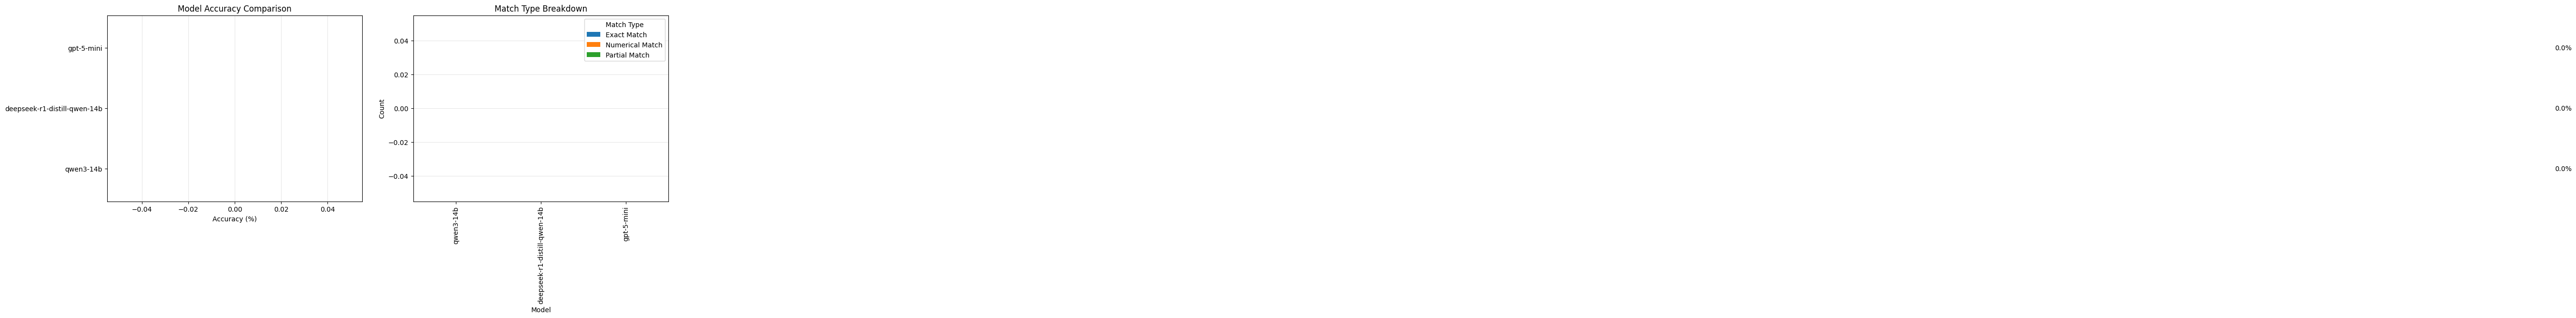


✓ Saved plot to: ../baseline results/model_comparison.png


In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy comparison
summary_df_sorted = summary_df.sort_values('Accuracy (%)', ascending=True)
axes[0].barh(summary_df_sorted['Model'], summary_df_sorted['Accuracy (%)'])
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(summary_df_sorted['Accuracy (%)']):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center')

# Plot 2: Match type breakdown
match_data = summary_df[['Model', 'Exact Match', 'Numerical Match', 'Partial Match']].set_index('Model')
match_data.plot(kind='bar', ax=axes[1], stacked=False)
axes[1].set_ylabel('Count')
axes[1].set_title('Match Type Breakdown')
axes[1].legend(title='Match Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(Path(config.output_dir) / "model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved plot to: {config.output_dir}/model_comparison.png")

## Error Analysis

In [ ]:
def analyze_errors(all_results: Dict[str, List[Dict]], n_examples: int = 5):
    """Show examples of incorrect answers for each model"""
    
    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        
        # Get incorrect results
        incorrect = [r for r in results if not r['correct']]
        
        if not incorrect:
            print(f"\n{model_short}: No errors! 🎉")
            continue
        
        print(f"\n{'='*80}")
        print(f"{model_short}: {len(incorrect)} errors")
        print(f"{'='*80}")
        
        # Show first n examples
        for i, error in enumerate(incorrect[:n_examples], 1):
            print(f"\nError {i}:")
            print(f"  Source: {error['source']}")
            print(f"  Question: {error['question'][:150]}...")
            print(f"  Ground truth: {error['ground_truth']}")
            print(f"  Extracted answer: {error['extracted_answer']}")
            print(f"  Model response: {error['model_response'][:200]}...")

# Show error examples
analyze_errors(all_results, n_examples=3)


qwen3-14b: 200 errors

Error 1:
  Source: [file_2] Example 3.15
  Question: Suppose that in the system shown in Figure 3.14 the two components have the same cost, and $R_{1}=0.7, R_{2}=0.95$. If it is permissible to add two co...
  Ground truth: 0.92435
  Extracted answer: EXTRACTION_ERROR
  Model response: ERROR: Error code: 401 - {'error': {'message': 'No cookie auth credentials found', 'code': 401}}...

Error 2:
  Source: [file_11] Example 4.11.
  Question: What is the reliability at MTTF?...
  Ground truth: 0.368
  Extracted answer: EXTRACTION_ERROR
  Model response: ERROR: Error code: 401 - {'error': {'message': 'No cookie auth credentials found', 'code': 401}}...

Error 3:
  Source: [file_11] Example 16.2
  Question: Twenty products are tested for 1000 hours. Fourteen products fail at the following times: 70, 128, 204, 291, 312, 377, 473, 549, 591, 663, 748, 827, 9...
  Ground truth: 1.3, 900
  Extracted answer: EXTRACTION_ERROR
  Model response: ERROR: Error code: 401 - {'error

## Export Detailed Results

In [ ]:
# Create a combined results file for easy comparison
combined_results = []

for i, item in enumerate(dataset):
    row = {
        'question_id': i,
        'source': item['source'],
        'question': item['question'],
        'ground_truth': item['answer']
    }
    
    # Add results from each model
    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        result = results[i]  # Assumes same order
        
        row[f'{model_short}_answer'] = result['extracted_answer']
        row[f'{model_short}_correct'] = result['correct']
    
    combined_results.append(row)

# Save as CSV
combined_df = pd.DataFrame(combined_results)
combined_df.to_csv(Path(config.output_dir) / "detailed_results.csv", index=False)

print(f"\n✓ Saved detailed results to: {config.output_dir}/detailed_results.csv")
print(f"\nColumns: {list(combined_df.columns)}")
print(f"Shape: {combined_df.shape}")


✓ Saved detailed results to: ../baseline results/detailed_results.csv

Columns: ['question_id', 'source', 'question', 'ground_truth', 'qwen3-14b_answer', 'qwen3-14b_correct', 'deepseek-r1-distill-qwen-14b_answer', 'deepseek-r1-distill-qwen-14b_correct', 'gpt-5-mini_answer', 'gpt-5-mini_correct']
Shape: (200, 10)


## Cost Analysis

In [ ]:
# Rough cost estimates (check OpenRouter pricing for exact rates)
COST_PER_1M_TOKENS = {
    'qwen/qwen-2.5-14b-instruct': 0.30,
    'deepseek/deepseek-r1-distill-qwen-14b': 0.40,
    'openai/gpt-4o-mini': 0.15,
    'google/gemini-flash-1.5': 0.075,
}

print("\n" + "="*80)
print("COST ANALYSIS")
print("="*80)

total_cost = 0

for model, tokens in total_tokens.items():
    model_short = model.split('/')[-1]
    cost_per_1m = COST_PER_1M_TOKENS.get(model, 0.50)  # Default if unknown
    cost = (tokens / 1_000_000) * cost_per_1m
    total_cost += cost
    
    print(f"{model_short}:")
    print(f"  Tokens: {tokens:,}")
    print(f"  Est. cost: ${cost:.4f}")

print(f"\nTotal estimated cost: ${total_cost:.4f}")
print("\nNote: These are rough estimates. Check OpenRouter for exact pricing.")


COST ANALYSIS

Total estimated cost: $0.0000

Note: These are rough estimates. Check OpenRouter for exact pricing.


## Summary and Recommendations

In [ ]:
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)

# Find best model
best_model_row = summary_df.loc[summary_df['Accuracy (%)'].idxmax()]

print(f"\n🏆 BEST MODEL: {best_model_row['Model']}")
print(f"   Accuracy: {best_model_row['Accuracy (%)']:.1f}%")
print(f"   Correct: {best_model_row['Correct']}/{best_model_row['Total']}")
print(f"   Tokens: {best_model_row['Tokens']:,}")

print(f"\n📊 ALL MODELS:")
for _, row in summary_df.sort_values('Accuracy (%)', ascending=False).iterrows():
    print(f"   {row['Model']}: {row['Accuracy (%)']:.1f}% ({row['Correct']}/{row['Total']})")

print(f"\n💰 COST EFFICIENCY:")
for model in config.models:
    model_short = model.split('/')[-1]
    tokens = total_tokens.get(model, 0)
    accuracy = summary_df[summary_df['Model'] == model_short]['Accuracy (%)'].values[0]
    cost_per_1m = COST_PER_1M_TOKENS.get(model, 0.50)
    cost = (tokens / 1_000_000) * cost_per_1m
    
    if accuracy > 0:
        cost_per_correct = (cost / accuracy) * 100
        print(f"   {model_short}: ${cost_per_correct:.6f} per correct answer")

print(f"\n📁 Results saved to: {config.output_dir}")
print(f"   - model_comparison.csv")
print(f"   - detailed_results.csv")
print(f"   - model_comparison.png")
print(f"   - [model_name]_results.json (individual model results)")

print("\n" + "="*80)


EVALUATION SUMMARY

🏆 BEST MODEL: qwen3-14b
   Accuracy: 0.0%
   Correct: 0/200
   Tokens: 0

📊 ALL MODELS:
   qwen3-14b: 0.0% (0/200)
   deepseek-r1-distill-qwen-14b: 0.0% (0/200)
   gpt-5-mini: 0.0% (0/200)

💰 COST EFFICIENCY:

📁 Results saved to: ../baseline results
   - model_comparison.csv
   - detailed_results.csv
   - model_comparison.png
   - [model_name]_results.json (individual model results)

